# **UT2 EJ2 PANDAS TEMPERATURAS - ALVARO FERNANDEZ BECERRA**

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#1 Carga los datos en 2 dataframes distintos.

df_paises = pd.read_csv("paises.csv")
df_temperaturas = pd.read_csv("temperaturas.csv")

#2 Muestra las primeras filas de cada dataframe:
print("DataFrame de países:")
print(df_paises.head(3))
print("\nDataFrame de temperaturas:")
df_temperaturas.head(3)

DataFrame de países:
   idpais cca2 cca3   nombre  capital  region        subregion  miembroONU  \
0    1909   MC  MCO   Monaco   Monaco  Europe   Western Europe           1   
1    1910   CY  CYP   Cyprus  Nicosia  Europe  Southern Europe           1   
2    1911   IE  IRL  Ireland   Dublin  Europe  Northern Europe           1   

   capitalLatitud  capitalLongitud  
0           43.73             7.42  
1           35.17            33.37  
2           53.32            -6.23  

DataFrame de temperaturas:


,idtemperaturas,idpais,timestamp,temperatura,sensacion,minima,maxima,humedad,amanecer,atardecer
0,2877,1909,2023-12-01 07:30:00,5.77,6.81,4.67,6.37,85,06:48:37,15:49:40
1,2878,1909,2023-12-02 07:30:00,14.27,15.18,13.57,17.15,94,06:49:00,15:52:16
2,2879,1909,2023-12-03 07:30:00,11.69,11.99,9.69,13.28,85,06:49:53,15:49:35


In [ ]:
#3.	Combina las dos tablas utilizando la columna 'idpais' como clave
df_combinado = pd.merge(df_paises, df_temperaturas, on='idpais')
print("\nDataFrame combinado:")
df_combinado.head(3)



DataFrame combinado:


,idpais,cca2,cca3,nombre,capital,region,subregion,miembroONU,capitalLatitud,capitalLongitud,idtemperaturas,timestamp,temperatura,sensacion,minima,maxima,humedad,amanecer,atardecer
0,1909,MC,MCO,Monaco,Monaco,Europe,Western Europe,1,43.73,7.42,2877,2023-12-01 07:30:00,5.77,6.81,4.67,6.37,85,06:48:37,15:49:40
1,1909,MC,MCO,Monaco,Monaco,Europe,Western Europe,1,43.73,7.42,2878,2023-12-02 07:30:00,14.27,15.18,13.57,17.15,94,06:49:00,15:52:16
2,1909,MC,MCO,Monaco,Monaco,Europe,Western Europe,1,43.73,7.42,2879,2023-12-03 07:30:00,11.69,11.99,9.69,13.28,85,06:49:53,15:49:35


In [16]:
#4.	Filtra los datos para mostrar solo los países de Europa. Para ello obtén primero los valores de la variable categórica necesaria.
df_europa = df_combinado[df_combinado['region'] == 'Europe']
print("\nDataFrame de países en Europa:")
df_europa.head(3)


DataFrame de países en Europa:


,idpais,cca2,cca3,nombre,capital,region,subregion,miembroONU,capitalLatitud,capitalLongitud,idtemperaturas,timestamp,temperatura,sensacion,minima,maxima,humedad,amanecer,atardecer
0,1909,MC,MCO,Monaco,Monaco,Europe,Western Europe,1,43.73,7.42,2877,2023-12-01 07:30:00,5.77,6.81,4.67,6.37,85,06:48:37,15:49:40
1,1909,MC,MCO,Monaco,Monaco,Europe,Western Europe,1,43.73,7.42,2878,2023-12-02 07:30:00,14.27,15.18,13.57,17.15,94,06:49:00,15:52:16
2,1909,MC,MCO,Monaco,Monaco,Europe,Western Europe,1,43.73,7.42,2879,2023-12-03 07:30:00,11.69,11.99,9.69,13.28,85,06:49:53,15:49:35



5. Temperatura media por país en Europa:
nombre
Albania                   10.374
Andorra                    9.845
Austria                   10.380
Belarus                    9.332
Belgium                    9.475
Bosnia and Herzegovina     9.476
Bulgaria                  10.928
Croatia                    9.679
Cyprus                     9.124
Czechia                    9.960
Denmark                    8.914
Estonia                   11.174
Faroe Islands              9.959
Finland                    9.570
France                     9.365
Germany                   10.324
Gibraltar                 10.131
Greece                     8.906
Guernsey                   8.726
Hungary                   10.985
Iceland                   11.203
Ireland                   10.144
Isle of Man               12.288
Italy                     10.751
Jersey                    11.662
Kosovo                     9.741
Latvia                     9.013
Liechtenstein              8.805
Lithuania                 1

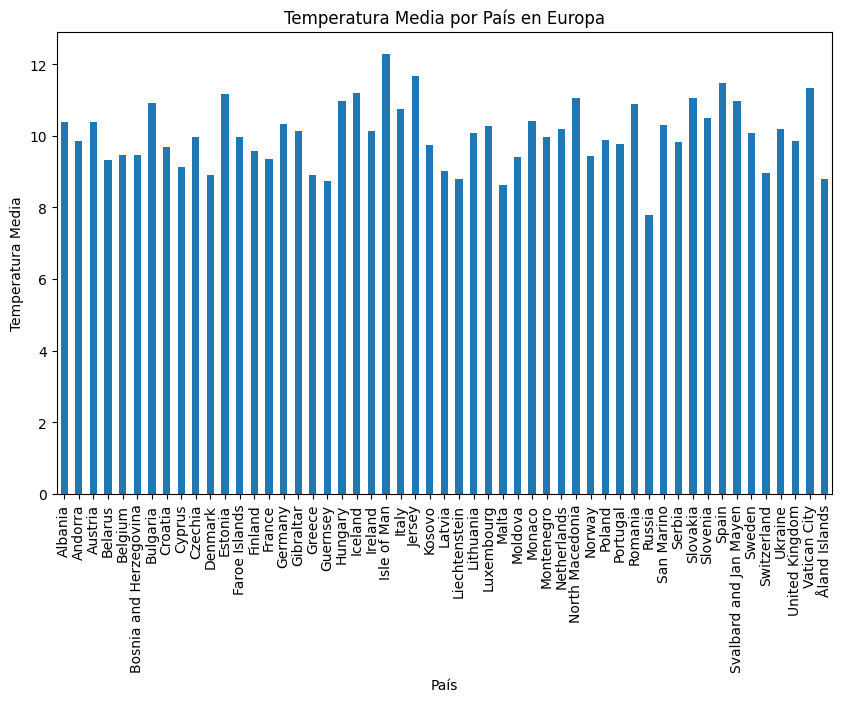

In [18]:
#5.	Calcula la temperatura media para cada país y muestra los resultados.
temperatura_media = df_europa.groupby('nombre')['temperatura'].mean()
print("\n5. Temperatura media por país en Europa:")
print(temperatura_media)

#6.	Crea un gráfico de barras mostrando la temperatura media de los países en Europa.
plt.figure(figsize=(10, 6))
temperatura_media.plot(kind='bar')
plt.title('Temperatura Media por País en Europa')
plt.xlabel('País')  
plt.ylabel('Temperatura Media')
plt.show()



7. País con la temperatura media más alta: Isle of Man (12.29°C)
   País con la temperatura media más baja: Russia (7.78°C)

8. Promedio de temperatura máxima en Europa: 11.79°C
   Promedio de temperatura mínima en Europa: 8.27°C


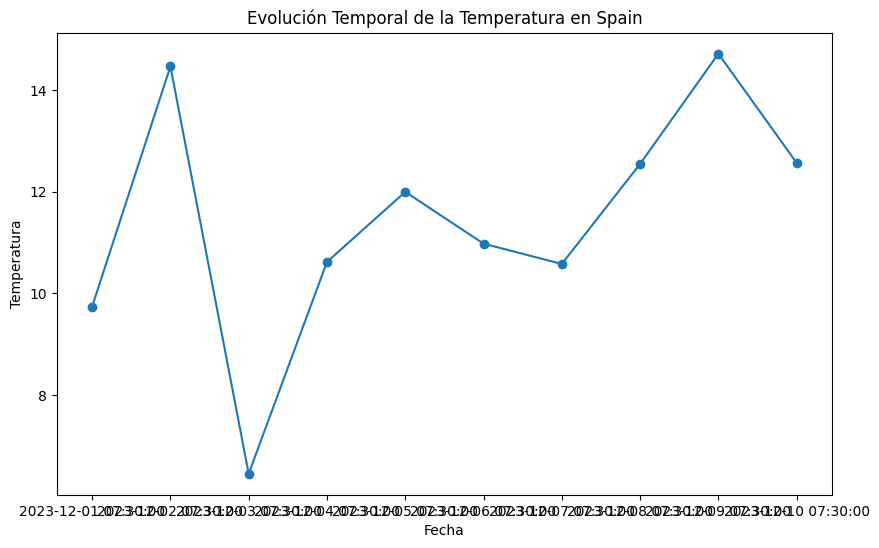

In [22]:
#7.	Encuentra el país con la temperatura media más alta y baja.
pais_max = temperatura_media.idxmax()
pais_min = temperatura_media.idxmin()
print(f"\n7. País con la temperatura media más alta: {pais_max} ({temperatura_media[pais_max]:.2f}°C)")
print(f"   País con la temperatura media más baja: {pais_min} ({temperatura_media[pais_min]:.2f}°C)")

#8.	Calcula el promedio de temperatura máxima y mínima en Europa.
temperatura_max_media = df_europa['maxima'].mean()
temperatura_min_media = df_europa['minima'].mean()
print(f"\n8. Promedio de temperatura máxima en Europa: {temperatura_max_media:.2f}°C")
print(f"   Promedio de temperatura mínima en Europa: {temperatura_min_media:.2f}°C")


#9.	Visualiza la evolución temporal de la temperatura para un país específico.
pais = 'Spain'
df_pais = df_combinado[df_combinado['nombre'] == pais]
plt.figure(figsize=(10, 6))
plt.plot(df_pais['timestamp'], df_pais['temperatura'], marker='o')
plt.title(f'Evolución Temporal de la Temperatura en {pais}')
plt.xlabel('Fecha')
plt.ylabel('Temperatura')
plt.show()

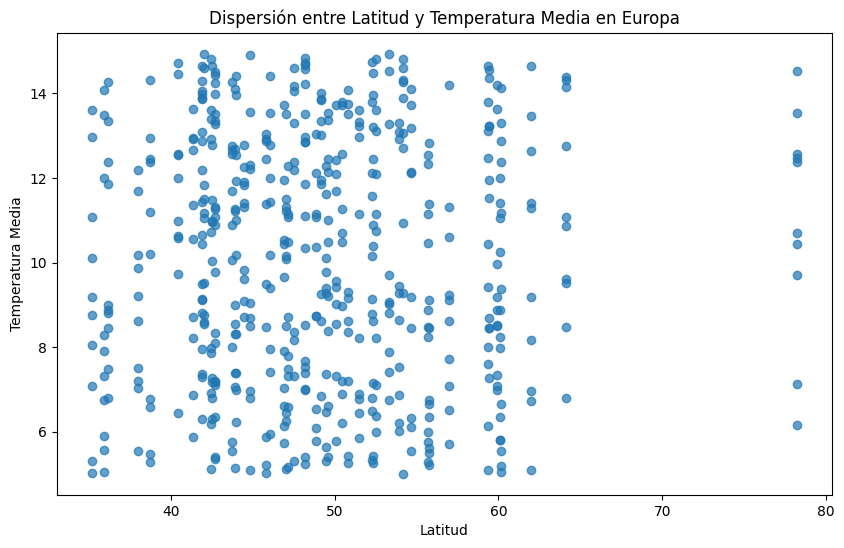

In [ ]:
#10.	Crea un gráfico de dispersión entre la latitud y la temperatura media de los países.
plt.figure(figsize=(10, 6))
plt.scatter(df_europa['capitalLatitud'], df_europa['temperatura'], alpha=0.7)
plt.title('Dispersión entre Latitud y Temperatura Media en Europa')
plt.xlabel('Latitud')
plt.ylabel('Temperatura Media')
plt.show()


In [25]:
#11.	Agrupa los datos por subregión y calcula la temperatura media para cada subregión.
temperatura_media_subregion = df_europa.groupby('subregion')['temperatura'].mean()
print("\n11. Temperatura media por subregión en Europa:")
temperatura_media_subregion


11. Temperatura media por subregión en Europa:


subregion
Central Europe      10.463500
Eastern Europe       9.178250
Northern Europe     10.115562
Southeast Europe    10.210778
Southern Europe     10.026600
Western Europe       9.726875
Name: temperatura, dtype: float64

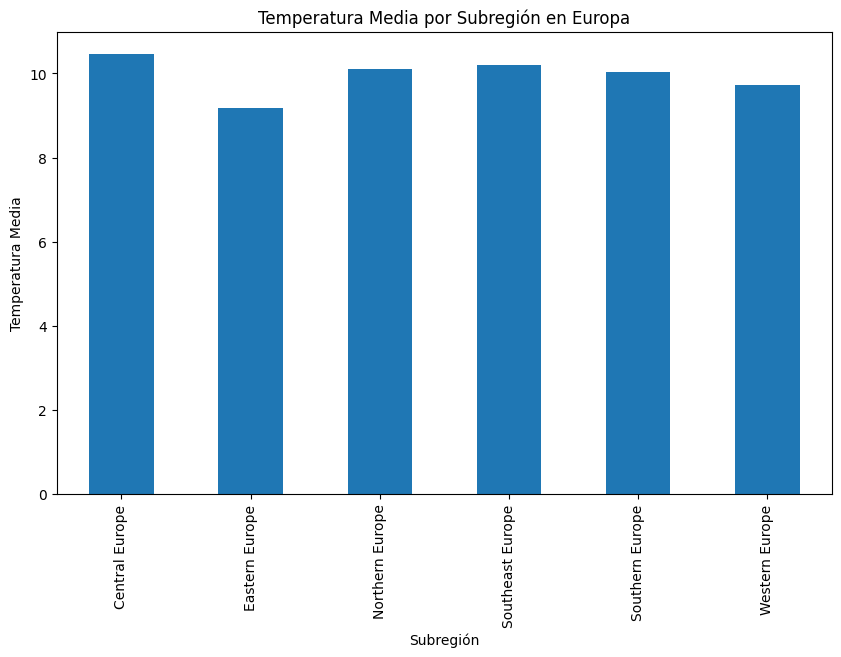

In [26]:
#12.	Crea un gráfico de barras apiladas mostrando la temperatura media por subregión.
plt.figure(figsize=(10, 6))
temperatura_media_subregion.plot(kind='bar', stacked=True)
plt.title('Temperatura Media por Subregión en Europa')
plt.xlabel('Subregión')
plt.ylabel('Temperatura Media')
plt.show()

In [27]:
#13.	Guarda los DataFrames resultantes en archivos CSV separados para futuros usos.
temperatura_media.to_csv('temperatura_media_paises_europa.csv', header=True)
temperatura_media_subregion.to_csv('temperatura_media_subregion_europa.csv', header=True)
